In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys, os
sys.path.insert(0, '/n/home12/binxuwang/Github/DiffusionAttnConsistency')

df = pd.read_pickle('/n/home12/binxuwang/Github/DiffusionAttnConsistency/outputs/parity_onset_table.pkl')
print(df.shape)
df.head(5)

(153, 29)


,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,318112.0,370336.0,444064.0,293536.0,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,358048.0,409248.0,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,345760.0,468640.0,629408.0,291488.0,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,422560.0,536224.0,706208.0,346784.0,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,248480.0,327328.0,430752.0,210592.0,0.100001,NaN,NaN,NaN,NaN,NaN


In [3]:
# Quick summary: how many runs reached rule / mem onset
for (arch, size), sub in df.groupby(['model_arch', 'model_size']):
    r = sub['rule_onset_acc90'].notna().sum()
    m = sub['mem_onset_mem10'].notna().sum()
    print(f"{arch}-{size:4s}: {r}/{len(sub)} rule onset,  {m}/{len(sub)} mem onset")

DiT-B   : 4/8 rule onset,  8/8 mem onset
DiT-mini: 38/68 rule onset,  42/68 mem onset
DiT-nano: 3/8 rule onset,  1/8 mem onset
GPT-B   : 16/16 rule onset,  16/16 mem onset
GPT-mini: 39/45 rule onset,  43/45 mem onset
GPT-nano: 8/8 rule onset,  8/8 mem onset


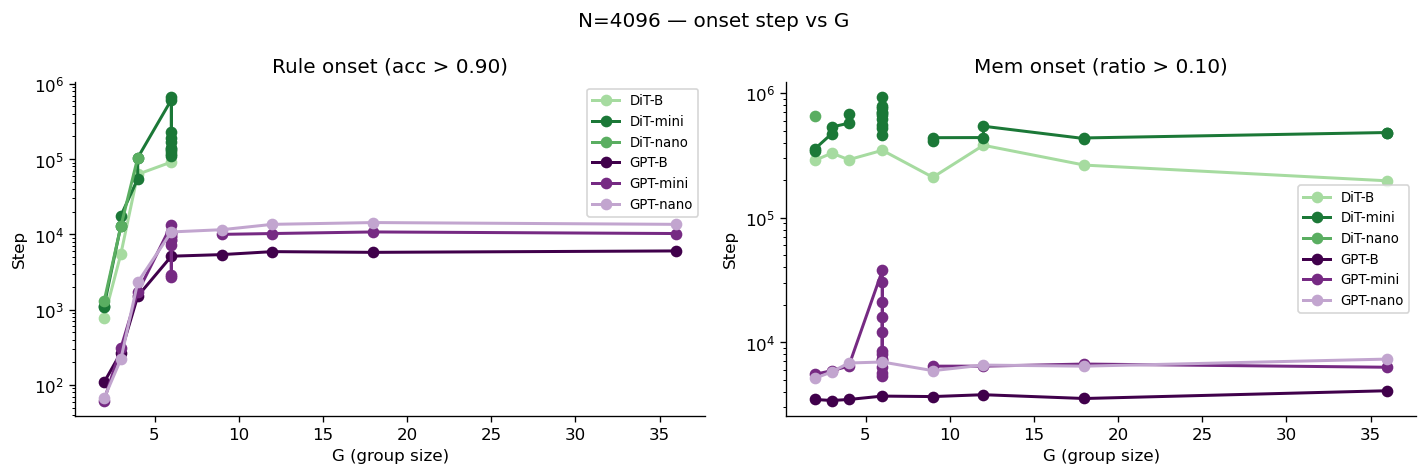

In [4]:
# ── Rule onset vs G, by arch/size ─────────────────────────────────────────
COLORS = {
    ('DiT', 'mini'): '#1b7837',
    ('DiT', 'B'):    '#a6dba0',
    ('GPT', 'mini'): '#762a83',
    ('GPT', 'nano'): '#c2a5cf',
    ('GPT', 'B'):    '#40004b',
    ('DiT', 'nano'): '#5aae61',
}

sub = df[df['N'] == 4096].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

for (arch, size), grp in sub.groupby(['model_arch', 'model_size']):
    grp = grp.sort_values('G')
    col = COLORS.get((arch, size), 'gray')
    label = f"{arch}-{size}"
    axes[0].plot(grp['G'], grp['rule_onset_acc90'], 'o-', color=col, lw=1.8, label=label)
    axes[1].plot(grp['G'], grp['mem_onset_mem10'],  'o-', color=col, lw=1.8, label=label)

for ax, title in [(axes[0], 'Rule onset (acc > 0.90)'), (axes[1], 'Mem onset (ratio > 0.10)')]:
    ax.set_yscale('log')
    ax.set_xlabel('G (group size)')
    ax.set_ylabel('Step')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('N=4096 — onset step vs G', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
df

,exp_name,model_arch,model_size,G,N,D,n_layer,n_embd,n_head,lr,...,mem_onset_mem20,mem_onset_mem35,mem_onset_mem50,mem_onset_stat,stat_mem_thresh,innov_acc90_mem10,innov_acc90_mem20,innov_acc90_mem35,innov_acc90_mem50,innov_acc90_stat
0,DiT_B_parity_N4096_D36_G2_even,DiT,B,2,4096,36,12,768,12,0.0001,...,318112.0,370336.0,444064.0,293536.0,0.115625,287644.0,317340.0,369564.0,443292.0,292764.0
1,DiT_B_parity_N4096_D36_G3_even,DiT,B,3,4096,36,12,768,12,0.0001,...,358048.0,409248.0,492192.0,329376.0,0.100244,323864.0,352536.0,403736.0,486680.0,323864.0
2,DiT_B_parity_N4096_D36_G4_even,DiT,B,4,4096,36,12,768,12,0.0001,...,345760.0,468640.0,629408.0,291488.0,0.100031,228688.0,282960.0,405840.0,566608.0,228688.0
3,DiT_B_parity_N4096_D36_G6_even,DiT,B,6,4096,36,12,768,12,0.0001,...,422560.0,536224.0,706208.0,346784.0,0.100004,255312.0,331088.0,444752.0,614736.0,255312.0
4,DiT_B_parity_N4096_D36_G9_even,DiT,B,9,4096,36,12,768,12,0.0001,...,248480.0,327328.0,430752.0,210592.0,0.100001,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,GPT_nano_parity_N4096_D36_G6_even,GPT,nano,6,4096,36,3,384,6,0.0001,...,7304.0,7816.0,8456.0,6920.0,0.100004,-3848.0,-3464.0,-2952.0,-2312.0,-3848.0
149,GPT_nano_parity_N4096_D36_G9_even,GPT,nano,9,4096,36,3,384,6,0.0001,...,6408.0,6920.0,7816.0,5896.0,0.100001,-5640.0,-5128.0,-4616.0,-3720.0,-5640.0
150,GPT_nano_parity_N4096_D36_G12_even,GPT,nano,12,4096,36,3,384,6,0.0001,...,7304.0,8072.0,8968.0,6536.0,0.100000,-7048.0,-6280.0,-5512.0,-4616.0,-7048.0
151,GPT_nano_parity_N4096_D36_G18_even,GPT,nano,18,4096,36,3,384,6,0.0001,...,7304.0,8456.0,9224.0,6408.0,0.100000,-7944.0,-7048.0,-5896.0,-5128.0,-7944.0


In [46]:
df = df.assign(model_str=df['model_arch'] + '-' + df['model_size'])

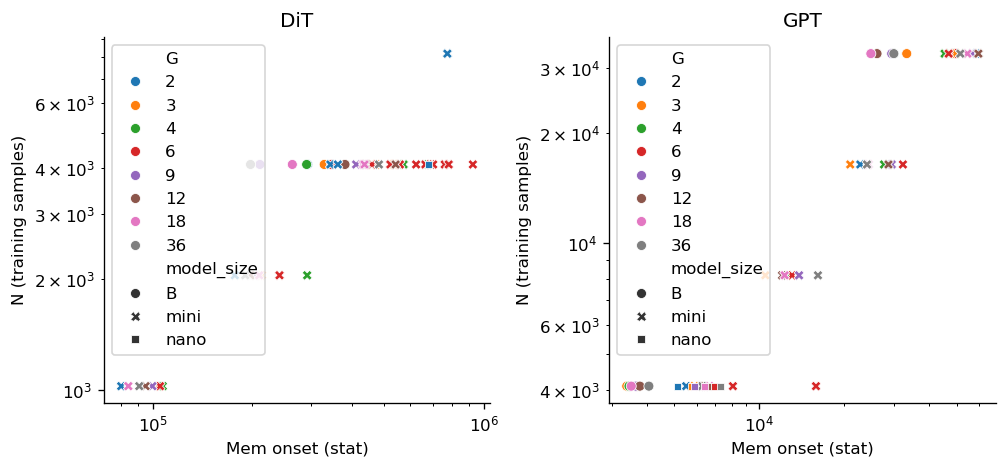

In [31]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" '), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Mem onset (stat)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Mem onset (stat)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

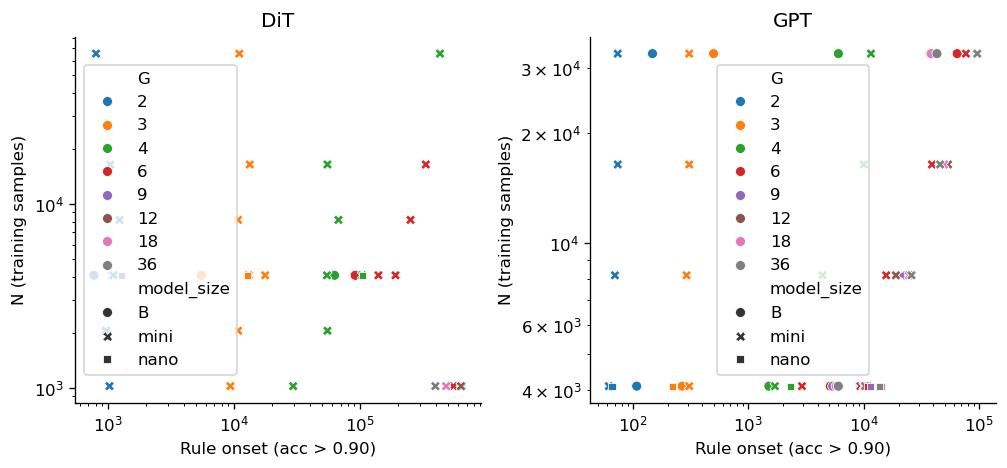

In [32]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00'), 
                x='rule_onset_acc90', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Rule onset (acc > 0.90)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01'), 
                x='rule_onset_acc90', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Rule onset (acc > 0.90)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

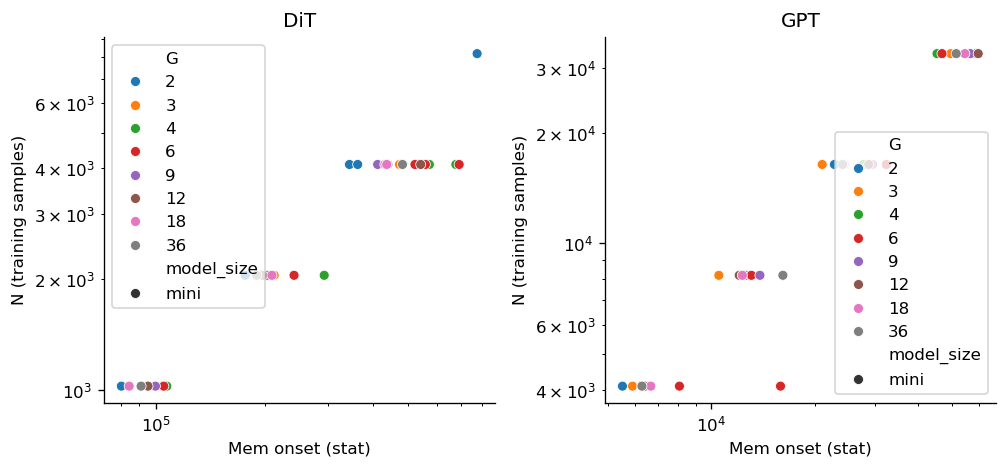

In [33]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4), dpi=120)
plt.sca(axes[0])
sns.scatterplot(data=df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Mem onset (stat)')
axes[0].set_ylabel('N (training samples)')
axes[0].set_title('DiT')
sns.scatterplot(data=df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"'), 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_size",
                palette="tab10", ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Mem onset (stat)')
axes[1].set_ylabel('N (training samples)')
axes[1].set_title('GPT')
plt.tight_layout()
fig.show()

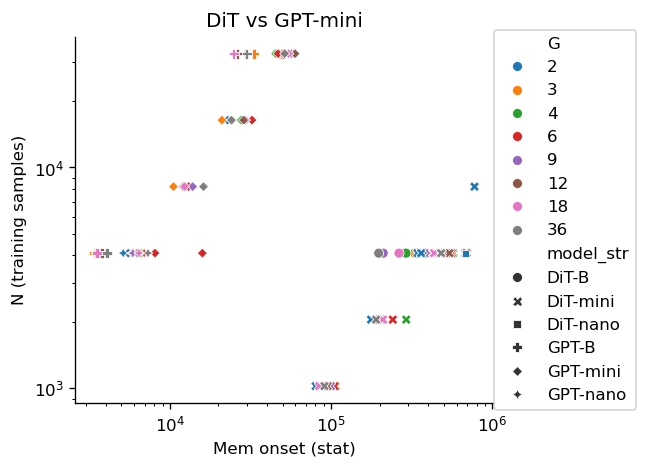

In [47]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 '), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 '), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_str",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-mini')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

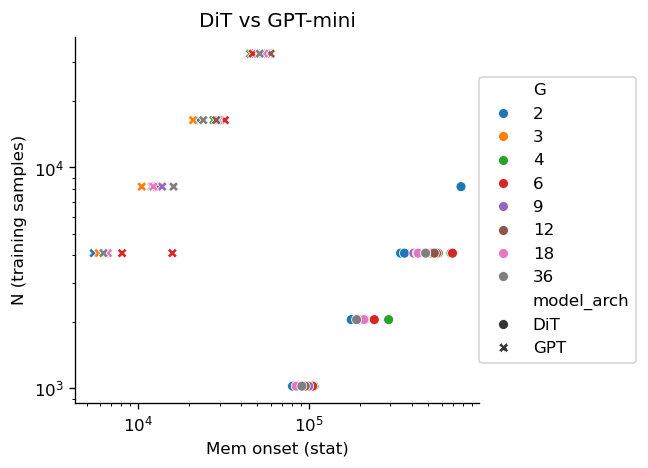

In [41]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "mini"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "mini"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-mini')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

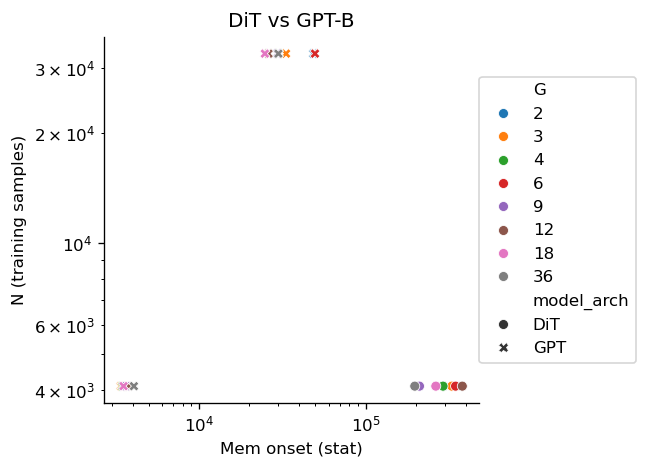

In [49]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "B"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "B"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-B')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

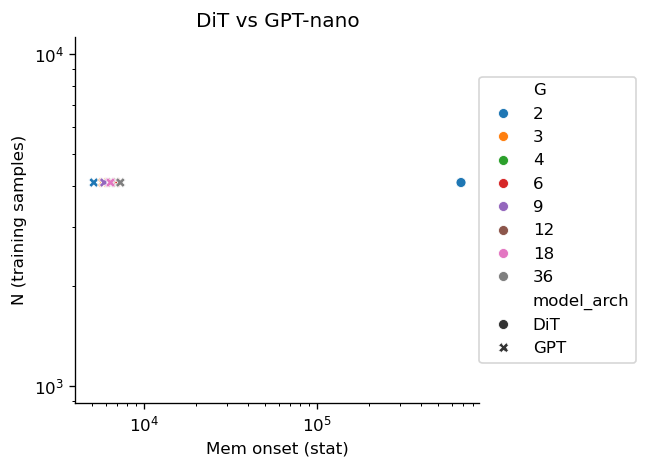

In [48]:
import seaborn as sns
fig, axes = plt.subplots(1, 1, figsize=(5.5, 4), dpi=120)
plt.sca(axes)
df_cmb = pd.concat([
    df.query('model_arch == "DiT" and lr == 0.0001 and wd == 0.00 and model_size == "nano"'), 
    df.query('model_arch == "GPT" and lr == 0.0001 and wd == 0.01 and model_size == "nano"'), 
    ], ignore_index=True)
scatter = sns.scatterplot(data=df_cmb, 
                x='mem_onset_stat', 
                y='N', hue='G', style="model_arch",
                palette="tab10", ax=axes)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlabel('Mem onset (stat)')
axes.set_ylabel('N (training samples)')
axes.set_title('DiT vs GPT-nano')
# Move the legend to outside right
axes.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.)
plt.tight_layout()
fig.show()

In [ ]:
# ── Innovation window vs G (N=4096, acc90 / mem10) ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

for (arch, size), grp in sub.groupby(['model_arch', 'model_size']):
    grp = grp.sort_values('G')
    col = COLORS.get((arch, size), 'gray')
    ax.plot(grp['G'], grp['innov_acc90_mem10'], 'o-', color=col, lw=1.8, label=f"{arch}-{size}")

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('G (group size)')
ax.set_ylabel('Innovation window (steps)\nmem_onset − rule_onset')
ax.set_title('Innovation window vs G  (N=4096, acc90/mem10)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

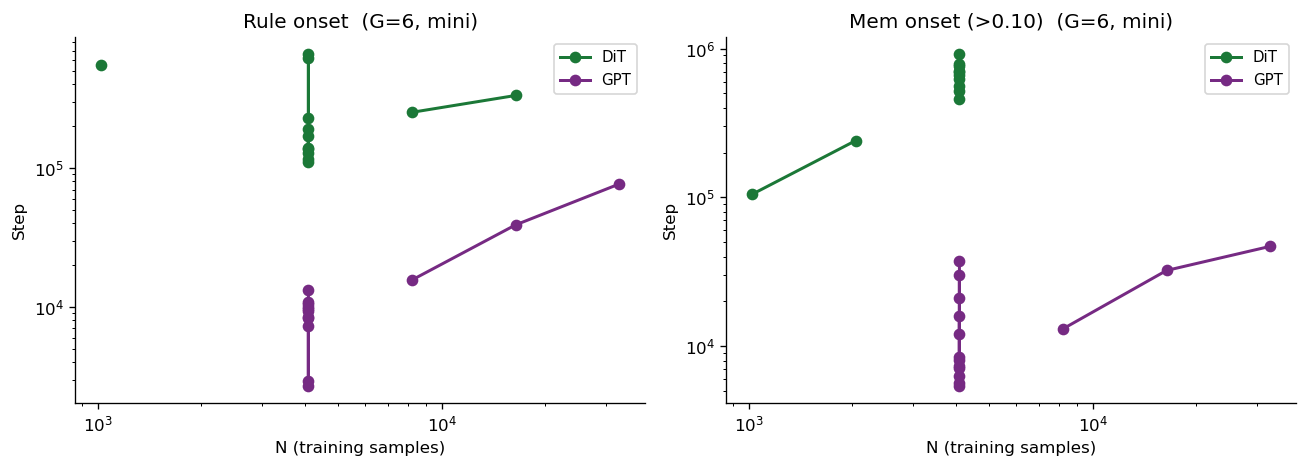

In [6]:
# ── Rule onset vs N for fixed G, DiT-mini vs GPT-mini ─────────────────────
G_FOCUS = 6
sub_g = df[(df['G'] == G_FOCUS) & (df['model_size'] == 'mini')].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

for arch, grp in sub_g.groupby('model_arch'):
    grp = grp.sort_values('N')
    col = COLORS.get((arch, 'mini'), 'gray')
    axes[0].plot(grp['N'], grp['rule_onset_acc90'], 'o-', color=col, lw=1.8, label=arch)
    axes[1].plot(grp['N'], grp['mem_onset_mem10'],  'o-', color=col, lw=1.8, label=arch)

for ax, title in [(axes[0], 'Rule onset'), (axes[1], 'Mem onset (>0.10)')]:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('N (training samples)')
    ax.set_ylabel('Step')
    ax.set_title(f"{title}  (G={G_FOCUS}, mini)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Raw table view: filter / inspect ──────────────────────────────────────
cols = ['exp_name', 'model_arch', 'model_size', 'G', 'N',
        'lr', 'wd', 'support_size', 'stat_mem_frac',
        'rule_onset_acc90', 'mem_onset_mem10', 'mem_onset_stat', 'innov_acc90_mem10']
df[cols].query("model_size == 'mini' and N == 4096").sort_values(['model_arch','G'])